In [12]:
# 必要なライブラリのimport
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import poisson

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [13]:
# データを読み込む
data1 = pd.read_csv('soccer_data.csv')

In [14]:
# データの確認
data1.head()

,Home,Away,Home_Goals,Away_Goals
0,G-Olympus,Koban,2,3
1,Hirostar,Urawind,1,0
2,Nagomi,Shimizun,1,0
3,Savan Taurus,C-Osario,0,0
4,Sapporia,Iwana,0,0


In [15]:
home_mean = data1['Home_Goals'].mean()
away_mean = data1['Away_Goals'].mean()

print(f'Homeチームのゴール数の平均: {home_mean:.4f}')
print(f'Awayチームのゴール数の平均: {away_mean:.4f}')

Homeチームのゴール数の平均: 1.4178
Awayチームのゴール数の平均: 1.2533


C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\3936411111.py:22: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\3936411111.py:22: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\3936411111.py:22: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\3936411111.py:22: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\3936411111.py:22: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\3936411111.py:22: UserWarning: Glyph 12391 (\N{HIRA

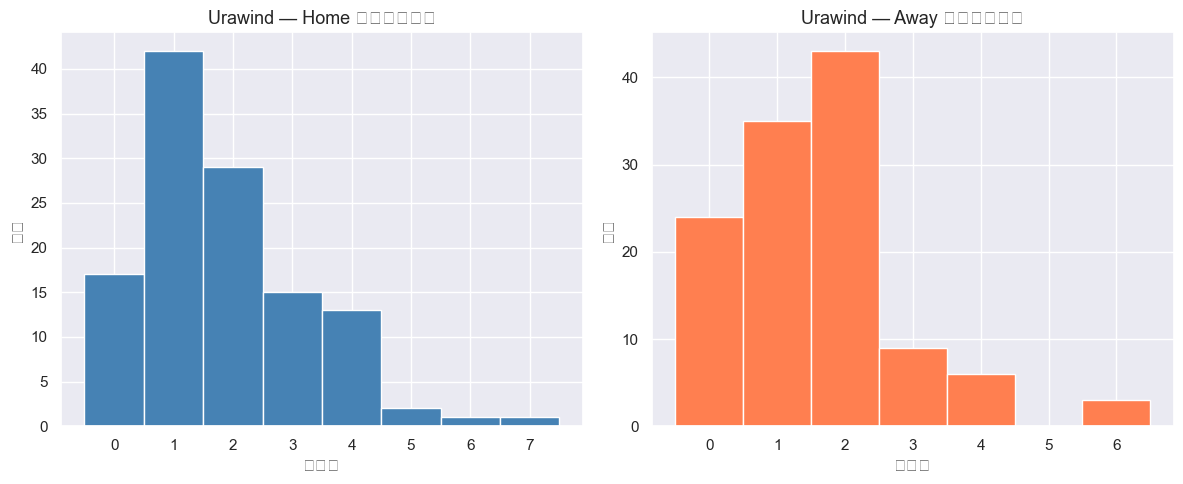

In [16]:
# Urawind のデータを抽出
urawind_home = data1[data1['Home'] == 'Urawind']['Home_Goals']
urawind_away = data1[data1['Away'] == 'Urawind']['Away_Goals']

# ヒストグラムを横並びで表示
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(urawind_home, bins=range(0, int(urawind_home.max()) + 2), color='steelblue',
             edgecolor='white', align='left')
axes[0].set_title('Urawind — Home での得点分布', fontsize=13)
axes[0].set_xlabel('得点数')
axes[0].set_ylabel('頻度')
axes[0].set_xticks(range(0, int(urawind_home.max()) + 1))

axes[1].hist(urawind_away, bins=range(0, int(urawind_away.max()) + 2), color='coral',
             edgecolor='white', align='left')
axes[1].set_title('Urawind — Away での得点分布', fontsize=13)
axes[1].set_xlabel('得点数')
axes[1].set_ylabel('頻度')
axes[1].set_xticks(range(0, int(urawind_away.max()) + 1))

plt.tight_layout()
plt.savefig('urawind_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\958280562.py:22: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\958280562.py:22: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\958280562.py:22: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\958280562.py:22: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\958280562.py:22: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_19252\958280562.py:22: UserWarning: Glyph 12391 (\N{HIRAGANA L

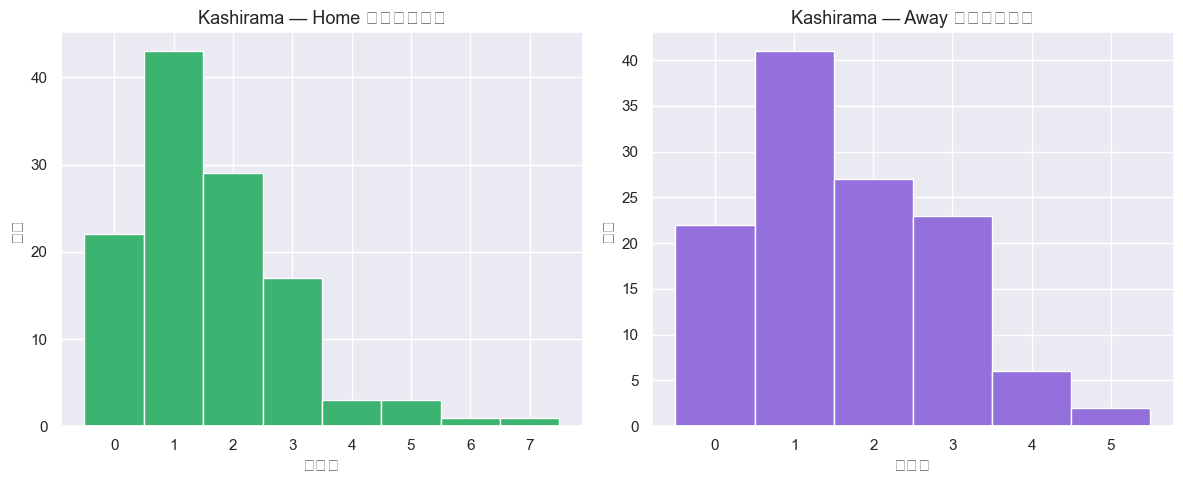

In [17]:
# Kashirama のデータを抽出
kashirama_home = data1[data1['Home'] == 'Kashirama']['Home_Goals']
kashirama_away = data1[data1['Away'] == 'Kashirama']['Away_Goals']

# ヒストグラムを横並びで表示
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(kashirama_home, bins=range(0, int(kashirama_home.max()) + 2), color='mediumseagreen',
             edgecolor='white', align='left')
axes[0].set_title('Kashirama — Home での得点分布', fontsize=13)
axes[0].set_xlabel('得点数')
axes[0].set_ylabel('頻度')
axes[0].set_xticks(range(0, int(kashirama_home.max()) + 1))

axes[1].hist(kashirama_away, bins=range(0, int(kashirama_away.max()) + 2), color='mediumpurple',
             edgecolor='white', align='left')
axes[1].set_title('Kashirama — Away での得点分布', fontsize=13)
axes[1].set_xlabel('得点数')
axes[1].set_ylabel('頻度')
axes[1].set_xticks(range(0, int(kashirama_away.max()) + 1))

plt.tight_layout()
plt.savefig('kashirama_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# モデル1: Away_Goals + Home + Away
model1 = smf.glm(
    formula='Home_Goals ~ Away_Goals + C(Home) + C(Away)',
    data=data1,
    family=sm.families.Poisson()
).fit()

# モデル2: Home + Away_Goals
model2 = smf.glm(
    formula='Home_Goals ~ C(Home) + Away_Goals',
    data=data1,
    family=sm.families.Poisson()
).fit()

In [20]:
# AIC が小さいほど良いモデル
if model1.aic < model2.aic:
    best_model = model1
    best_model_name = 'モデル1（Away_Goals + Home + Away）'
else:
    best_model = model2
    best_model_name = 'モデル2（Home + Away_Goals）'

print(f'最適モデル: {best_model_name}')
print(f'AIC: {best_model.aic:.4f}')
print('\n' + '='*60)
print(best_model.summary())

最適モデル: モデル1（Away_Goals + Home + Away）
AIC: 6448.8577

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Home_Goals   No. Observations:                 2140
Model:                            GLM   Df Residuals:                     2087
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3171.4
Date:                Sun, 22 Mar 2026   Deviance:                       2433.7
Time:                        22:35:04   Pearson chi2:                 2.13e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.1027
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [22]:
# --- 7-1. Away が 0 点のときの Home 得点予測 ---
pred_data_0 = pd.DataFrame({'Home': ['Urawind'], 'Away': ['Kashirama'], 'Away_Goals': [0]})
pred_0 = best_model.predict(pred_data_0)
print(f'Awayが 0 点のときの Home（Urawind）得点予測値: {pred_0.values[0]:.4f}')

# --- 7-2. Away が 2 点のときの Home 得点予測 ---
pred_data_2 = pd.DataFrame({'Home': ['Urawind'], 'Away': ['Kashirama'], 'Away_Goals': [2]})
pred_2 = best_model.predict(pred_data_2)
print(f'Awayが 2 点のときの Home（Urawind）得点予測値: {pred_2.values[0]:.4f}')

# --- 7-3. Kashirama の Away 平均得点 ---
kashirama_away_mean = data1[data1['Away'] == 'Kashirama']['Away_Goals'].mean()
print(f'\nKashirama の Away 平均得点（λ）: {kashirama_away_mean:.4f}')

Awayが 0 点のときの Home（Urawind）得点予測値: 1.5753
Awayが 2 点のときの Home（Urawind）得点予測値: 1.7301

Kashirama の Away 平均得点（λ）: 1.6364


In [23]:
# --- 7-4. ポアソン分布から Away 得点を 100 個生成 ---
np.random.seed(42)  # 再現性のためシードを固定
lam = kashirama_away_mean
away_scores = np.random.poisson(lam, 100)

print(f'生成した Away 得点（100試合分）:')
print(away_scores)
print(f'\n平均: {away_scores.mean():.4f}  最小: {away_scores.min()}  最大: {away_scores.max()}')

生成した Away 得点（100試合分）:
[3 0 0 0 3 2 0 0 1 1 1 1 2 2 1 0 4 2 1 2 1 1 6 1 1 2 1 0 1 2 0 4 1 2 0 1 4
 4 2 0 0 2 2 1 0 1 5 4 0 1 2 2 0 2 2 3 1 0 2 2 0 2 2 2 2 2 0 2 1 1 3 1 3 3
 0 3 4 1 0 2 0 1 0 3 1 2 3 1 2 4 1 2 1 4 5 2 0 4 2 4]

平均: 1.6800  最小: 0  最大: 6


In [24]:
# --- 7-5. 100 試合分の Home 得点を繰り返し処理で予測 ---
home_predicted_list = []

for away_score in away_scores:
    pred_input = pd.DataFrame({'Home': ['Urawind'], 'Away': ['Kashirama'], 'Away_Goals': [away_score]})
    predicted_home = best_model.predict(pred_input).values[0]
    home_predicted_list.append(predicted_home)

# ndarray に変換
home_predicted = np.array(home_predicted_list)

print('Home（Urawind）の予測得点（100試合分）:')
print(home_predicted)
print(f'\n平均: {home_predicted.mean():.4f}  最小: {home_predicted.min():.4f}  最大: {home_predicted.max():.4f}')

Home（Urawind）の予測得点（100試合分）:
[1.81314557 1.57532506 1.57532506 1.57532506 1.81314557 1.73012909
 1.57532506 1.57532506 1.6509136  1.6509136  1.6509136  1.6509136
 1.73012909 1.73012909 1.6509136  1.57532506 1.90014541 1.73012909
 1.6509136  1.73012909 1.6509136  1.6509136  2.08686889 1.6509136
 1.6509136  1.73012909 1.6509136  1.57532506 1.6509136  1.73012909
 1.57532506 1.90014541 1.6509136  1.73012909 1.57532506 1.6509136
 1.90014541 1.90014541 1.73012909 1.57532506 1.57532506 1.73012909
 1.73012909 1.6509136  1.57532506 1.6509136  1.99131975 1.90014541
 1.57532506 1.6509136  1.73012909 1.73012909 1.57532506 1.73012909
 1.73012909 1.81314557 1.6509136  1.57532506 1.73012909 1.73012909
 1.57532506 1.73012909 1.73012909 1.73012909 1.73012909 1.73012909
 1.57532506 1.73012909 1.6509136  1.6509136  1.81314557 1.6509136
 1.81314557 1.81314557 1.57532506 1.81314557 1.90014541 1.6509136
 1.57532506 1.73012909 1.57532506 1.6509136  1.57532506 1.81314557
 1.6509136  1.73012909 1.81314557 1.650

In [25]:
# --- 7-6. Urawind が勝つ確率 ---
# Home 得点 > Away 得点 のとき Urawind の勝ち
win_flags = home_predicted > away_scores
win_count = win_flags.sum()
win_prob = win_count / len(away_scores)

print(f'100 試合のシミュレーション結果:')
print(f'  Urawind 勝利数: {win_count} 試合')
print(f'  Urawind 勝率  : {win_prob:.2%}')

100 試合のシミュレーション結果:
  Urawind 勝利数: 49 試合
  Urawind 勝率  : 49.00%
